In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from msfm.utils import files

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import dataset, preprocessing, input_output

2025-10-24 05:16:02.178969: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 05:16:02.179002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 05:16:02.180127: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-24 05:16:02.187482: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-24 05:16:04.307858: W tensorflow/compiler/tf2

# configuration

In [3]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/marcel/simple.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/marcel"

n_side = msfm_conf["analysis"]["n_side"]

cosmo_params = ["Om", "s8", "w0"]
lensing_params = ["Aia", "n_Aia"]
clustering_params = ["bg", "n_bg"]

In [4]:
probe = "lensing"
# probe = "clustering"
# probe = "combined"

if probe == "lensing":
    params = cosmo_params + lensing_params
    n_z = 4
elif probe == "clustering":
    params = cosmo_params + clustering_params
    n_z = 4
elif probe == "combined":
    params = cosmo_params + lensing_params + clustering_params
    n_z = 8

# dataset

In [13]:
file_dict = input_output.load_human_summaries(
    base_dir,
    "cls",
    cls_from_maps=False,
    return_raw_cls=False,
)
fidu_summs = file_dict[f"fiducial/cls/binned"]
grid_summs = file_dict[f"grid/cls/binned"]


25-10-24 04:57:29 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/marcel 
25-10-24 04:57:29 input_output INF   Array shapes: 
25-10-24 04:57:29 input_output INF   fiducial/i_example = (33080,) 
25-10-24 04:57:29 input_output INF   fiducial/i_noise   = (33080,) 
25-10-24 04:57:29 input_output INF   fiducial/cls/binned = (33080, 32, 36) 
25-10-24 04:57:29 input_output INF   fiducial/cls/bin_edges = (33, 36) 
25-10-24 04:57:29 input_output INF   grid/cosmo         = (2500, 400, 12) 
25-10-24 04:57:29 input_output INF   grid/i_example     = (2500, 400) 
25-10-24 04:57:29 input_output INF   grid/i_noise       = (2500, 400) 
25-10-24 04:57:29 input_output INF   grid/i_sobol       = (2500, 400) 
25-10-24 04:57:30 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
25-10-24 04:57:30 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
25-10-24 04:57:30 input_output INF   Done loading the summaries after 0:00:00.74 


In [15]:
grid_summs.shape

(2500, 400, 32, 36)

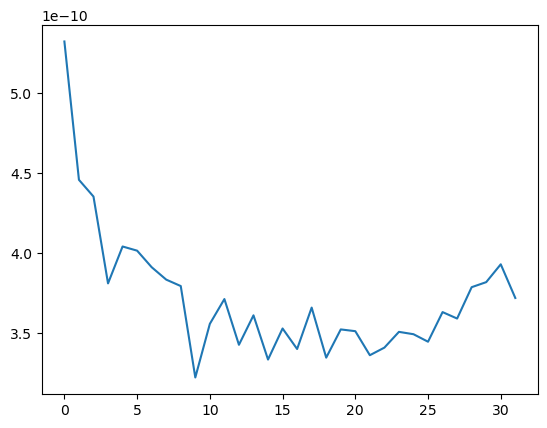

In [16]:
plt.plot(grid_summs[0,0,:,0])

In [8]:
with h5py.File("/pscratch/sd/a/athomsen/v11desy3/marcel/cls/grid_cls.h5", "r") as f:
    print(f.keys())
    grid_cls = f["cls"]

<KeysViewHDF5 ['cls', 'cosmo', 'i_example', 'i_noise', 'i_sobol']>


25-10-24 05:08:16 preprocessin INF   Loading the pre-binned Cls 
25-10-24 05:08:16 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/marcel 
25-10-24 05:08:16 input_output INF   Array shapes: 
25-10-24 05:08:16 input_output INF   fiducial/i_example = (33080,) 
25-10-24 05:08:16 input_output INF   fiducial/i_noise   = (33080,) 
25-10-24 05:08:16 input_output INF   fiducial/cls/binned = (33080, 32, 36) 
25-10-24 05:08:16 input_output INF   fiducial/cls/bin_edges = (33, 36) 
25-10-24 05:08:16 input_output INF   grid/cosmo         = (2500, 400, 12) 
25-10-24 05:08:16 input_output INF   grid/i_example     = (2500, 400) 
25-10-24 05:08:16 input_output INF   grid/i_noise       = (2500, 400) 
25-10-24 05:08:16 input_output INF   grid/i_sobol       = (2500, 400) 
25-10-24 05:08:17 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
25-10-24 05:08:17 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
25-10-24 05:08:17 input_output INF   Done loading the sum

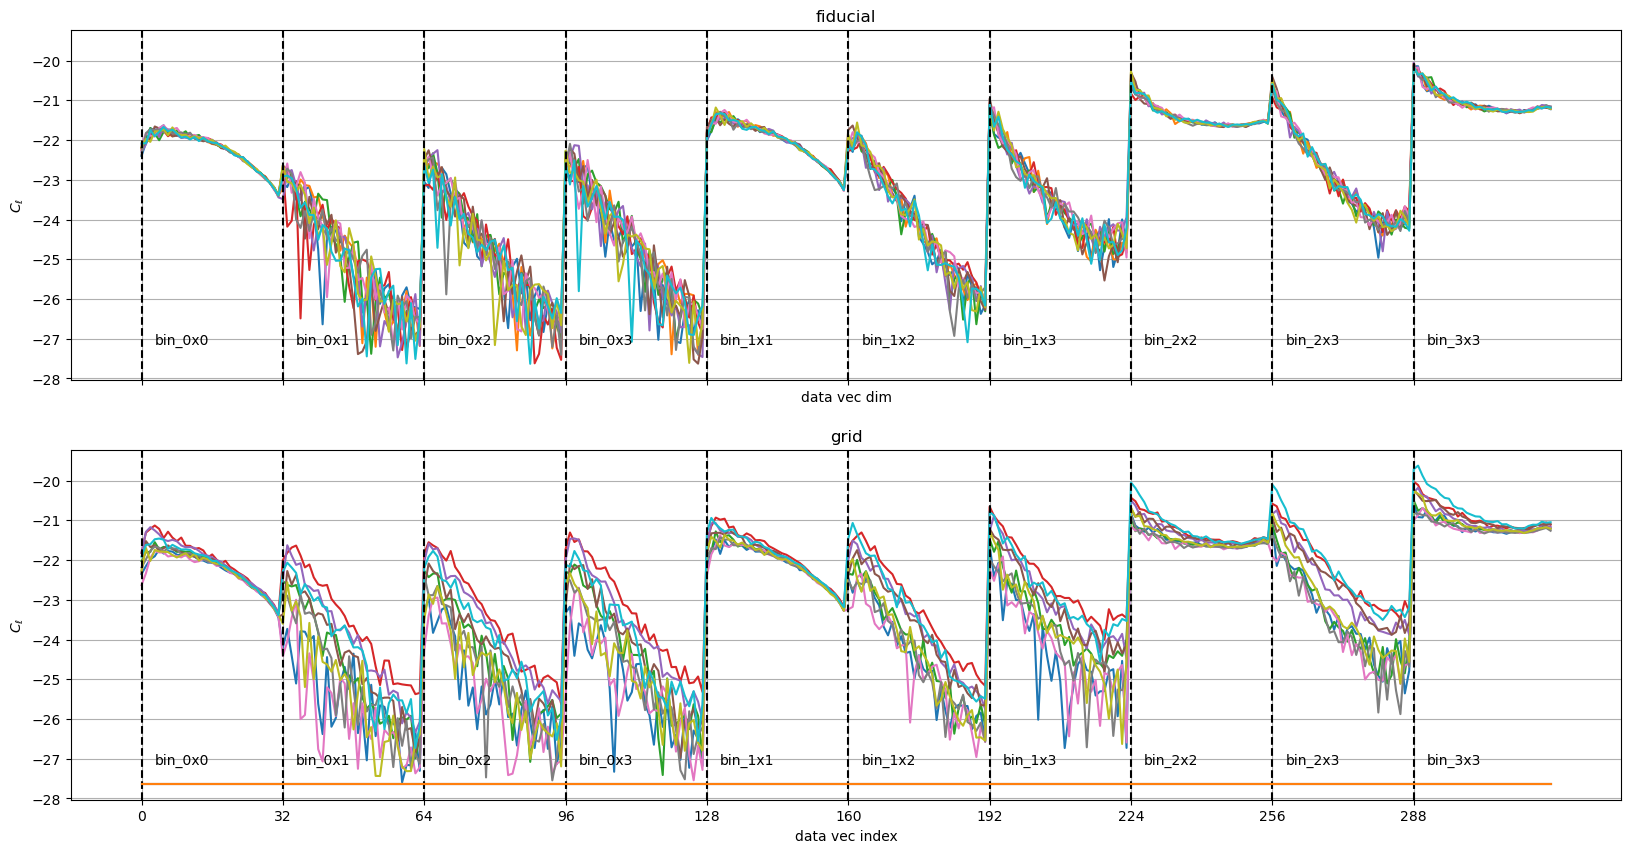

In [23]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
# apply_log = False
standardize = False
# l_mins = [0.0] * 4
l_mins = [30.0] * 4
l_maxs = [3 * n_side] * 4
sigmas = [0.0] * n_z

cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    params=params,
    # selection
    probe=probe,
    # with_gaussian_noise=True,
    with_gaussian_noise=False,
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    white_noise_sigmas=sigmas,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

plt.plot(out_dict["grid/cls/train"][0,:])
plt.plot(out_dict["grid/cls/test"][0,:])

25-10-24 05:21:23 preprocessin INF   Loading the pre-binned Cls 
25-10-24 05:21:23 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/marcel 
25-10-24 05:21:23 input_output INF   Array shapes: 
25-10-24 05:21:23 input_output INF   fiducial/i_example = (33080,) 
25-10-24 05:21:23 input_output INF   fiducial/i_noise   = (33080,) 
25-10-24 05:21:23 input_output INF   fiducial/cls/binned = (33080, 32, 36) 
25-10-24 05:21:23 input_output INF   fiducial/cls/bin_edges = (33, 36) 
25-10-24 05:21:23 input_output INF   grid/cosmo         = (2500, 400, 12) 
25-10-24 05:21:23 input_output INF   grid/i_example     = (2500, 400) 
25-10-24 05:21:23 input_output INF   grid/i_noise       = (2500, 400) 
25-10-24 05:21:23 input_output INF   grid/i_sobol       = (2500, 400) 
25-10-24 05:21:23 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
25-10-24 05:21:23 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
25-10-24 05:21:23 input_output INF   Done loading the sum

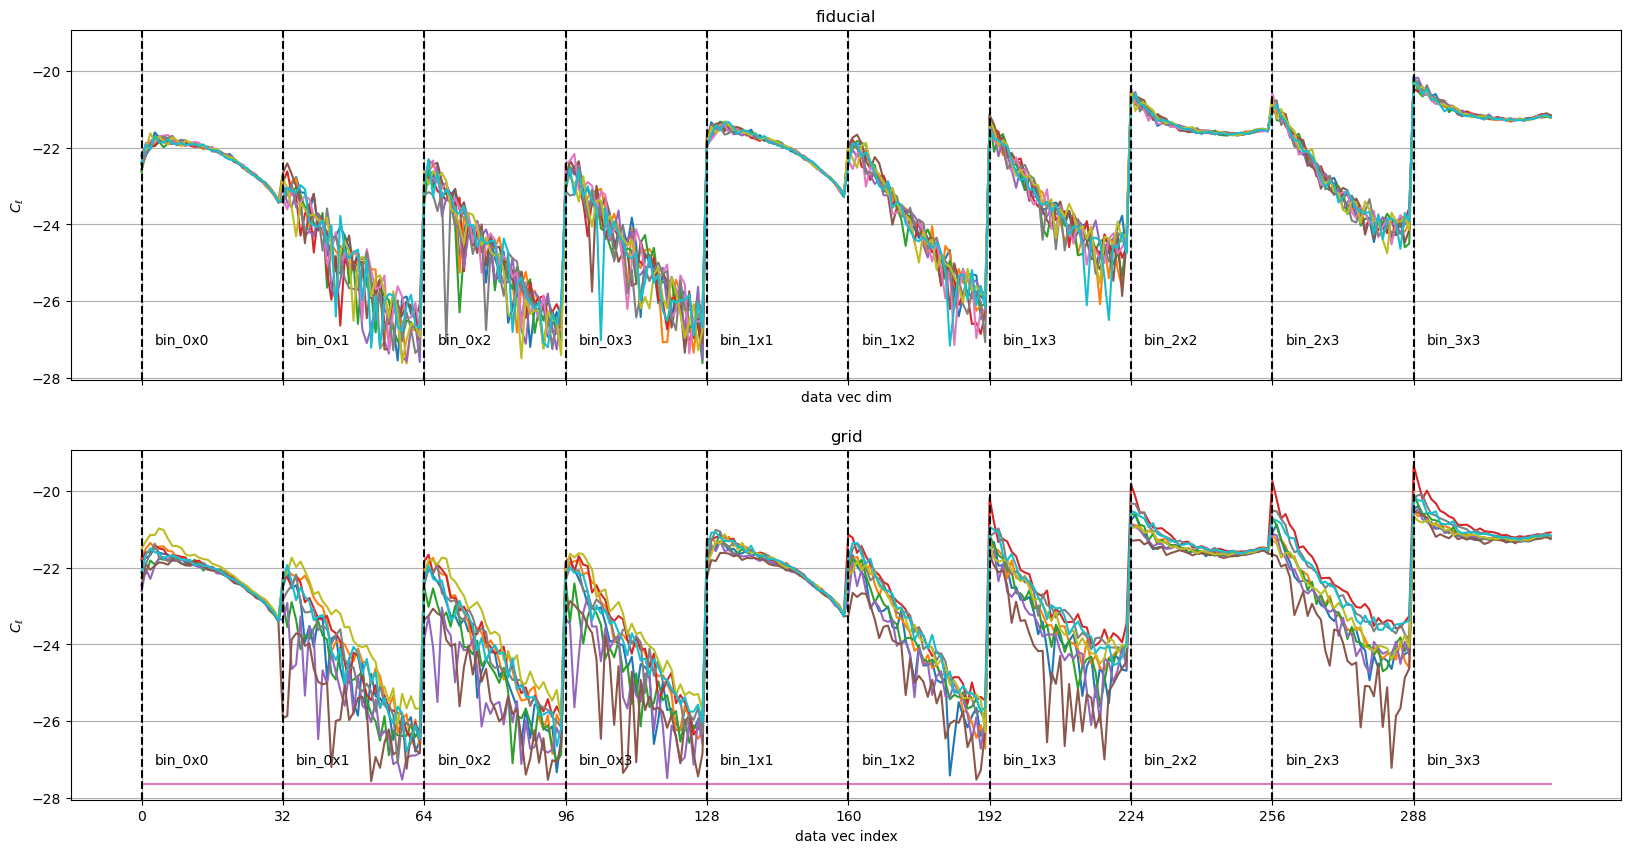

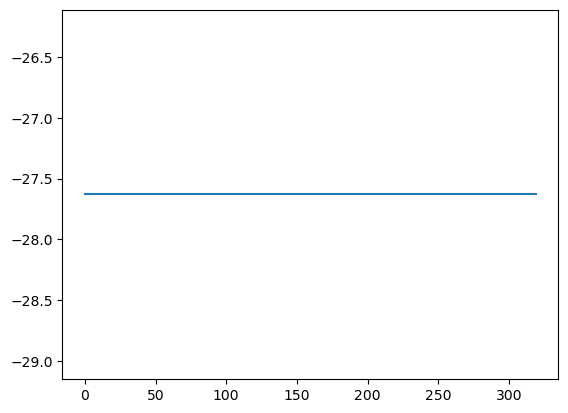

In [12]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
# apply_log = False
standardize = False
# l_mins = [0.0] * 4
l_mins = [30.0] * 4
l_maxs = [3 * n_side] * 4
sigmas = [0.0] * n_z

out_dict = preprocessing.get_binned_power_spectra(
# grid_cls = preprocessing.get_binned_power_spectra(
    base_dir=base_dir,
    # configuration
    msfm_conf=msfm_conf,
    params=params,
    concat_bin_dim=True,
    # selection
    with_lensing=True,
    with_clustering=False,
    # Cls scale cuts
    l_mins=l_mins,
    l_maxs=l_maxs,
    with_gaussian_noise=False,
    white_noise_sigmas=sigmas,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

fig, ax = plt.subplots()
grid_cls = out_dict["grid/cls/train"]
ax.plot(grid_cls[4653,:])

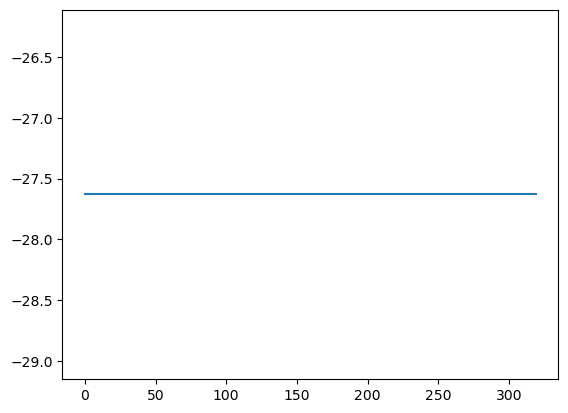

In [7]:
plt.plot(grid_cls[0,:])

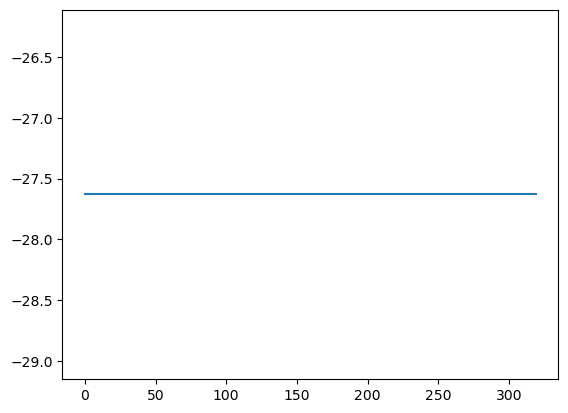

In [31]:
grid_cls = out_dict["grid/cls/train"]
plt.plot(grid_cls[0,:])

In [21]:
grid_cls = out_dict["grid/cls/train"]
print(grid_cls.shape)

(800000, 320)


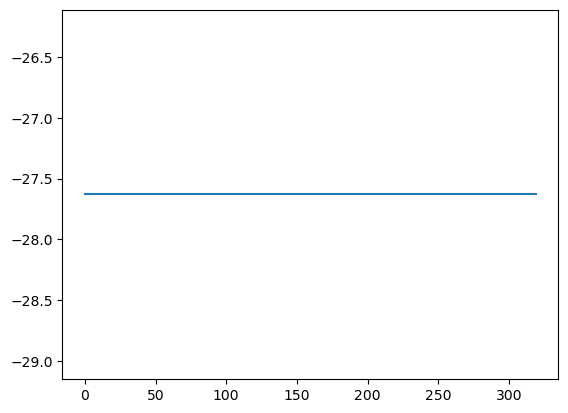

In [24]:
plt.plot(grid_cls[1000,:])

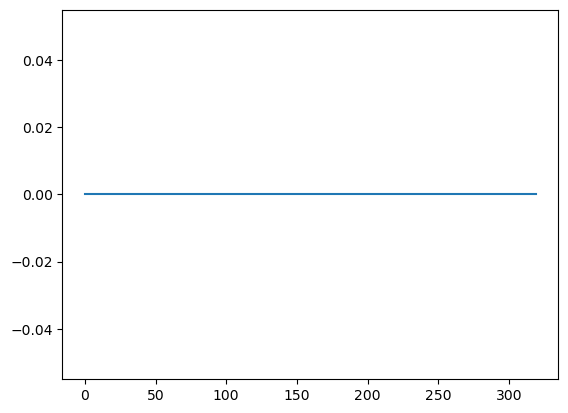

In [34]:
plt.plot(out_dict["grid/cls_raw/train"][0,:])

In [ ]:
stop

# trash

In [6]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

cosine_decay = False
n_steps = 100_000

out_dir = os.path.join(out_dir_base, "cls/mutual_info")
if with_lensing and not with_clustering:
    out_dir = os.path.join(out_dir, "lensing")
elif with_clustering and not with_lensing:
    out_dir = os.path.join(out_dir, "clustering")
elif with_lensing and with_clustering:
    out_dir = os.path.join(out_dir, "combined")
out_dir = os.path.join(out_dir, f"standard={standardize},log={apply_log},steps={n_steps}")

# label += "_lmin=113" 
    
if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

print("base_dir = ", base_dir)
print("out_dir = ", out_dir)

NameError: name 'out_dir_base' is not defined

In [ ]:
bins = power_spectra.get_cl_bins(
    msfm_conf["analysis"]["power_spectra"]["l_min"], 
    msfm_conf["analysis"]["power_spectra"]["l_max"], 
    msfm_conf["analysis"]["power_spectra"]["n_bins"]
)
print(bins[-28:])

In [ ]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # keep_last_i_bins=28,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

# hard cut dset

In [ ]:
# l_mins = [0.0] * 4
# l_maxs = [3 * n_side] * 4

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     params=params,
#     # selection
#     with_lensing=True,
#     with_clustering=True,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     n_bins=32,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )